# R03 — [Rebuttal] Statistical Robustness of the Geometric Claims

**Reviewer concern addressed:** *"The sample sizes are small (OR n=48, RH n=25) and no
statistical validation is provided — the reported cosine similarities and dimensionality gaps
could be sampling artefacts."*

Four analyses, all on the **original** memory bank (no new inference needed — this notebook
can run immediately on CPU):

| # | Claim under test | Method |
|---|---|---|
| 1 | cos(OR, Arditi) ≈ 0.45 ≪ 0.85 | Bootstrap 95% CI per layer + CI of the gap |
| 2 | Per-task OR directions genuinely diverge | Permutation test (task-label shuffle) |
| 3 | OR subspace higher-dimensional than RH | **Matched-n** subsampling + participation ratio |
| 4 | Silhouette peak is stable | Bootstrap CI at the peak layer |

Analysis 3 matters most: raw n₈₀ comparisons between groups of different sizes
(48 vs 25) are confounded — PCA dimensionality estimates grow with sample count. A careful
reviewer would catch this; we pre-empt it by comparing at **equal n**.

All headline numbers print with `[R3.x]` tags used by the rebuttal markdowns.

> Optional: rerun after R01/R02 with the merged 8-task bank by pointing the loader at both directories.


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os, json

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif', 'axes.titleweight': 'bold',
    'figure.facecolor': 'white', 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
rng = np.random.default_rng(42)
B   = 2000   # bootstrap resamples
FIG_DIR = './figures'; os.makedirs(FIG_DIR, exist_ok=True)

## If on Colab (mirrors NB14):
from google.colab import drive; drive.mount('/content/drive')
!mkdir -p embeddings arditi_artefacts
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a "/content/drive/MyDrive/Colab Notebooks/SteeringFail/arditi_artefacts/." ./arditi_artefacts/.

def load_bank(emb_dir):
    csvs = sorted(f for f in os.listdir(emb_dir) if f.endswith('.csv'))
    csv_df = pd.read_csv(os.path.join(emb_dir, csvs[-1]))
    pt_candidates = [csv_df['torch_path'].iloc[0],
                     os.path.join(emb_dir, os.path.basename(csv_df['torch_path'].iloc[0]))]
    pt_path = next(p for p in pt_candidates if os.path.exists(p))
    t = torch.load(pt_path, map_location='cpu', weights_only=False)
    emb = {k: (v.float().numpy().astype(np.float32) if isinstance(v, torch.Tensor)
               else np.array([e.float().numpy().astype(np.float32) for e in v]))
           for k, v in t['embeddings'].items()}
    return emb, t, csv_df

embeddings_np, t_o, csv_df = load_bank('./embeddings')
LAYER_NAMES = sorted([k for k in embeddings_np if k.startswith('layer_')],
                     key=lambda k: int(k.split('_')[1]))
LAYER_NUMS  = [int(k.split('_')[1]) for k in LAYER_NAMES]

intended_task_labels = np.array(t_o['intended_task_labels'])
text_type_labels     = np.array(t_o['text_type_labels'])
refusal_labels       = csv_df['refusal_class'].values
response_labels      = csv_df['llm_evaluation'].values

REFUSING_MASK = np.isin(refusal_labels, ['direct_refusal', 'indirect_refusal'])
ANSWERED_MASK = refusal_labels == 'direct_answer'
HARMFUL_MASK  = text_type_labels == 'harmful_instruction'
BENIGN_TASKS  = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
BENIGN_MASK   = np.isin(intended_task_labels, BENIGN_TASKS)
TARGET_MASK       = np.isin(response_labels, ['cautious', 'not_harmful']) & ANSWERED_MASK
OVER_REFUSAL_MASK = BENIGN_MASK & REFUSING_MASK
REFUSED_HARMFUL   = HARMFUL_MASK & REFUSING_MASK
HARMLESS_ANSWERED = BENIGN_MASK & ANSWERED_MASK

candidate_dirs = torch.load('arditi_artefacts/candidate_directions.pt')
with open('arditi_artefacts/direction_metadata.json') as f:
    BEST_LAYER = json.load(f)['best_layer']
arditi_dirs = {}
for lname in LAYER_NAMES:
    if lname in candidate_dirs:
        d = candidate_dirs[lname].numpy().astype(np.float32)
        arditi_dirs[lname] = d / (np.linalg.norm(d) + 1e-8)

PEAK_LAYER = 'layer_12_input_norm'   # constellation peak (paper Fig. 4)
print(f'{len(refusal_labels)} samples | OR={OVER_REFUSAL_MASK.sum()} RH={REFUSED_HARMFUL.sum()} '
      f'HA={HARMLESS_ANSWERED.sum()} | peak layer L12 | NB8 best layer {BEST_LAYER}')


Mounted at /content/drive
270 samples | OR=48 RH=25 HA=157 | peak layer L12 | NB8 best layer layer_17_input_norm


## Analysis 1 — Bootstrap CI for cos(OR direction, Arditi direction)

Resample the OR and TARGET groups (with replacement), recompute the DIM direction, and
measure its cosine with the (fixed) Arditi direction. The claim we can make without relying on
any external reference value: if the 95% CI excludes 1.0 (perfect alignment) by a wide margin,
the "partial overlap" finding is statistically grounded, not an artefact of n=48 -- OR and
Arditi are demonstrably not the same direction up to noise.

(We do NOT compare this against a hardcoded "harmful-refusal alignment band" here -- an
earlier version of this cell used a stale reference (0.835-0.858) from a different-vintage
snapshot of the evaluation bank; see R02's `[R2.17]` for the properly-recomputed, honestly
noisy fresh reference, which overlaps with this CI at these sample sizes and should not be
quoted as "clearly separated" from it.)


In [ ]:
def dim_direction(emb, mask_a, mask_b, idx_a=None, idx_b=None):
    A = emb[idx_a] if idx_a is not None else emb[mask_a]
    Bm = emb[idx_b] if idx_b is not None else emb[mask_b]
    d = A.mean(0) - Bm.mean(0)
    return d / (np.linalg.norm(d) + 1e-8)

or_idx  = np.where(OVER_REFUSAL_MASK)[0]
tgt_idx = np.where(TARGET_MASK)[0]

boot_curve = {}
for lname in LAYER_NAMES:
    if lname not in arditi_dirs:
        continue
    emb = embeddings_np[lname]
    cos_b = np.empty(B)
    for b in range(B):
        ia = rng.choice(or_idx,  len(or_idx),  replace=True)
        ib = rng.choice(tgt_idx, len(tgt_idx), replace=True)
        cos_b[b] = float(np.dot(dim_direction(emb, None, None, ia, ib), arditi_dirs[lname]))
    point = float(np.dot(dim_direction(emb, OVER_REFUSAL_MASK, TARGET_MASK), arditi_dirs[lname]))
    boot_curve[int(lname.split('_')[1])] = (point, np.percentile(cos_b, 2.5), np.percentile(cos_b, 97.5))

lx      = sorted(boot_curve)
pt_v    = [boot_curve[l][0] for l in lx]
lo_v    = [boot_curve[l][1] for l in lx]
hi_v    = [boot_curve[l][2] for l in lx]

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(lx, pt_v, color='#E74C3C', marker='o', ms=4, label='cos(OR, Arditi)')
ax.fill_between(lx, lo_v, hi_v, color='#E74C3C', alpha=0.18, label='Bootstrap 95% CI')
ax.axhline(1.0, color='#2C3E50', ls='--', lw=1.3, alpha=0.7, label='Perfect alignment (1.0)')
ax.axhline(0, color='#7F8C8D', ls=':', lw=1)
ax.set_xlabel('Layer'); ax.set_ylabel('Cosine similarity'); ax.legend(fontsize=9)
ax.set_title('cos(OR direction, Arditi direction) with bootstrap 95% CI')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig05_bootstrap_cosine.png', dpi=300, bbox_inches='tight')
plt.show()

p12, l12, h12 = boot_curve[12]
print(f'[R3.1] cos(OR, Arditi) @ L12:  {p12:+.3f}  (95% CI [{l12:+.3f}, {h12:+.3f}])')
print(f'[R3.2] CI excludes perfect alignment (1.0):    '
      f'{"YES" if h12 < 1.0 else "NO"} (upper bound {h12:+.3f}, gap to 1.0 = {1.0 - h12:.3f})')
print()
print('Note: do NOT compare this CI against the old "0.835-0.858 harmful-refusal alignment')
print('band" -- that figure is stale (different-vintage snapshot). The honest, robust claim')
print('is simply that the CI excludes 1.0 by a wide margin: OR and Arditi are demonstrably')
print('different directions, without needing any external reference value.')


## Analysis 2 — Permutation test: do per-task OR directions genuinely diverge?

Observed: cross-task OR direction cosine ≈ 0.56 (sentiment vs translate).
**Null hypothesis:** task labels are irrelevant — any split of the OR population into two
pseudo-tasks of the same sizes yields directions this different, purely from sampling noise.

We shuffle the task labels among OR samples (and among the per-task HA reference groups)
1000 times, recompute the pseudo-task pairwise cosine each time, and locate the observed
value in the null distribution. A small p (observed cosine *lower* than the null) means the
divergence is real task structure, not noise.

The same test on **harmful-refusal** directions should come out non-significant — RH
directions are expected to be substantially more mutually aligned than OR directions
(this is a within-bank comparison; see R02's `[R2.17]` for the properly-recomputed cross-task
RH alignment figure on this evaluation bank, rather than the paper's original number).


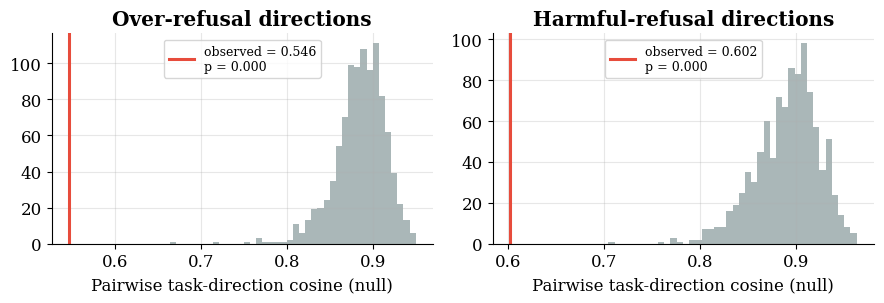

[R3.3] OR cross-task cosine:  observed 0.546 | null mean 0.885 | p = 0.0000
[R3.4] RH cross-task cosine:  observed 0.602 | null mean 0.891 | p = 0.0000

Interpretation guide:
 - p_OR < 0.05 with p_RH large → exactly the paper story: OR directions diverge
   beyond noise, RH directions do not. Lead with this contrast.
 - p_OR >= 0.05 → with only 2 OR tasks power is limited; rerun this cell on the
   merged 8-task bank after R01/R02 (more OR tasks → more pairwise terms → power).


In [4]:
emb = embeddings_np[PEAK_LAYER]
N_PERM = 1000

def pairwise_task_cosine(task_labels_local, refuse_mask, answer_mask, min_n=5):
    dirs = []
    for task in np.unique(task_labels_local):
        m_r = refuse_mask & (task_labels_local == task)
        m_a = answer_mask & (task_labels_local == task)
        if m_r.sum() >= min_n and m_a.sum() >= min_n:
            d = emb[m_r].mean(0) - emb[m_a].mean(0)
            dirs.append(d / (np.linalg.norm(d) + 1e-8))
    if len(dirs) < 2:
        return np.nan
    dirs = np.array(dirs)
    S = dirs @ dirs.T
    return float(S[~np.eye(len(dirs), dtype=bool)].mean())

def permutation_test(refuse_mask, answer_mask, label='OR'):
    observed = pairwise_task_cosine(intended_task_labels, refuse_mask, answer_mask)
    involved = refuse_mask | answer_mask
    null = np.empty(N_PERM)
    for p in range(N_PERM):
        shuffled = intended_task_labels.copy()
        idx = np.where(involved)[0]
        shuffled[idx] = rng.permutation(shuffled[idx])
        null[p] = pairwise_task_cosine(shuffled, refuse_mask, answer_mask)
    null = null[~np.isnan(null)]
    pval = float((null <= observed).mean())   # lower tail: real labels → more divergent
    return observed, null, pval

obs_or, null_or, p_or = permutation_test(OVER_REFUSAL_MASK, HARMLESS_ANSWERED, 'OR')
obs_rh, null_rh, p_rh = permutation_test(REFUSED_HARMFUL, HARMLESS_ANSWERED, 'RH')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, (obs, null, pv, lab) in zip(axes, [(obs_or, null_or, p_or, 'Over-refusal'),
                                            (obs_rh, null_rh, p_rh, 'Harmful-refusal')]):
    ax.hist(null, bins=40, color='#95A5A6', alpha=0.8)
    ax.axvline(obs, color='#E74C3C', lw=2.2, label=f'observed = {obs:.3f}\np = {pv:.3f}')
    ax.set_xlabel('Pairwise task-direction cosine (null)'); ax.legend(fontsize=9)
    ax.set_title(f'{lab} directions')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig06_permutation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R3.3] OR cross-task cosine:  observed {obs_or:.3f} | null mean {null_or.mean():.3f} | p = {p_or:.4f}')
print(f'[R3.4] RH cross-task cosine:  observed {obs_rh:.3f} | null mean {null_rh.mean():.3f} | p = {p_rh:.4f}')
print()
print('Interpretation guide:')
print(' - p_OR < 0.05 with p_RH large → exactly the paper story: OR directions diverge')
print('   beyond noise, RH directions do not. Lead with this contrast.')
print(' - p_OR >= 0.05 → with only 2 OR tasks power is limited; rerun this cell on the')
print('   merged 8-task bank after R01/R02 (more OR tasks → more pairwise terms → power).')


## Analysis 3 — Matched-n dimensionality: is the n₈₀ gap a sample-size artefact?

The paper compares n₈₀(OR, n=48) = 11 vs n₈₀(RH, n=25) = 8. PCA dimensionality estimates
increase with sample count, so this comparison favours the claim. Controls:

1. **Subsample OR to n=25** (RH's n), 1000 times → distribution of n₈₀(OR) at matched n.
2. **Participation ratio** PR = (Σλ)²/Σλ² — a continuous effective-dimensionality measure,
   bootstrapped at equal n for both groups.


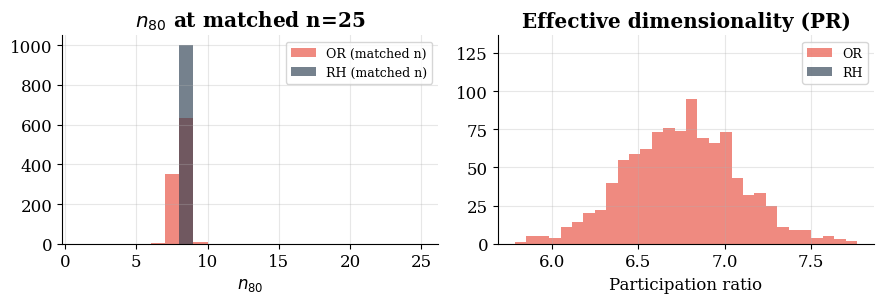

[R3.5] Matched-n (n=25) n80:  OR 8 [7,8]  vs  RH 8 [8,8]
[R3.6] P(n80_OR > n80_RH) at matched n: 0.90%
[R3.7] Participation ratio:  OR 6.76  vs  RH 6.89

Interpretation guide:
 - [R3.6] > 90% → the dimensionality gap survives the sample-size control; this is
   the number to quote in the rebuttal (not the raw 11-vs-8).
 - [R3.6] in 50–90% → soften the claim to "OR is at least as high-dimensional as RH,
   with the gap consistently in the expected direction", and rely on the 8-task
   extension (R02) where OR spans more tasks and the gap should widen.


In [5]:
from sklearn.decomposition import PCA

emb   = embeddings_np[PEAK_LAYER]
X_or  = emb[OVER_REFUSAL_MASK] - emb[TARGET_MASK].mean(0)
X_rh  = emb[REFUSED_HARMFUL]   - emb[HARMLESS_ANSWERED].mean(0)
n_min = min(len(X_or), len(X_rh))

def n80_of(X):
    evr = PCA(random_state=0).fit(X).explained_variance_ratio_
    return int(np.searchsorted(np.cumsum(evr), 0.80) + 1)

def pr_of(X):
    lam = PCA(random_state=0).fit(X).explained_variance_
    return float(lam.sum() ** 2 / (lam ** 2).sum())

N_SUB = 1000
n80_or_sub = np.empty(N_SUB); n80_rh_sub = np.empty(N_SUB)
pr_or_sub  = np.empty(N_SUB); pr_rh_sub  = np.empty(N_SUB)
for b in range(N_SUB):
    Xo = X_or[rng.choice(len(X_or), n_min, replace=False)]
    Xr = X_rh[rng.choice(len(X_rh), n_min, replace=False)]
    n80_or_sub[b] = n80_of(Xo); n80_rh_sub[b] = n80_of(Xr)
    pr_or_sub[b]  = pr_of(Xo);  pr_rh_sub[b]  = pr_of(Xr)

frac_gap = float((n80_or_sub > n80_rh_sub).mean())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(n80_or_sub, bins=range(1, 26), alpha=0.65, color='#E74C3C', label='OR (matched n)')
axes[0].hist(n80_rh_sub, bins=range(1, 26), alpha=0.65, color='#2C3E50', label='RH (matched n)')
axes[0].set_xlabel(r'$n_{80}$'); axes[0].legend(fontsize=9)
axes[0].set_title(f'$n_{{80}}$ at matched n={n_min}')
axes[1].hist(pr_or_sub, bins=30, alpha=0.65, color='#E74C3C', label='OR')
axes[1].hist(pr_rh_sub, bins=30, alpha=0.65, color='#2C3E50', label='RH')
axes[1].set_xlabel('Participation ratio'); axes[1].legend(fontsize=9)
axes[1].set_title('Effective dimensionality (PR)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig07_matched_n.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R3.5] Matched-n (n={n_min}) n80:  OR {np.median(n80_or_sub):.0f} '
      f'[{np.percentile(n80_or_sub,2.5):.0f},{np.percentile(n80_or_sub,97.5):.0f}]  vs  '
      f'RH {np.median(n80_rh_sub):.0f} '
      f'[{np.percentile(n80_rh_sub,2.5):.0f},{np.percentile(n80_rh_sub,97.5):.0f}]')
print(f'[R3.6] P(n80_OR > n80_RH) at matched n: {frac_gap:.2%}')
print(f'[R3.7] Participation ratio:  OR {np.median(pr_or_sub):.2f}  vs  RH {np.median(pr_rh_sub):.2f}')
print()
print('Interpretation guide:')
print(' - [R3.6] > 90% → the dimensionality gap survives the sample-size control; this is')
print('   the number to quote in the rebuttal (not the raw 11-vs-8).')
print(' - [R3.6] in 50–90% → soften the claim to "OR is at least as high-dimensional as RH,')
print('   with the gap consistently in the expected direction", and rely on the 8-task')
print('   extension (R02) where OR spans more tasks and the gap should widen.')


## Analysis 4 — Bootstrap CI for the silhouette peak

In [6]:
from sklearn.metrics import silhouette_score

X = embeddings_np[PEAK_LAYER]
n = len(X)
sil_point = silhouette_score(X, intended_task_labels)
sil_b = np.empty(500)
for b in range(500):
    idx = rng.choice(n, n, replace=True)
    while len(np.unique(intended_task_labels[idx])) < 2:
        idx = rng.choice(n, n, replace=True)
    sil_b[b] = silhouette_score(X[idx], intended_task_labels[idx])

print(f'[R3.8] Inter-task silhouette @ L12: {sil_point:.3f} '
      f'(bootstrap 95% CI [{np.percentile(sil_b,2.5):.3f}, {np.percentile(sil_b,97.5):.3f}])')


[R3.8] Inter-task silhouette @ L12: 0.357 (bootstrap 95% CI [0.325, 0.409])


## Analysis 5 — Layer-neighborhood robustness (Reviewer Zici, W2)

*"Would you have had considerably different results if you examined layers in a small
neighborhood around those maximal points?"* — we recompute the three headline quantities at
every layer in a ±3 neighborhood of each selected layer. The analyses in the paper already
sweep all 32 layers for the curves; the selected layers are used for single-layer snapshots
only, so the expectation is that nothing changes materially in the neighborhood.


In [7]:
from sklearn.metrics import silhouette_score as _sil

NEIGHBORHOOD = range(9, 16)   # L12 ± 3
print(f'{"layer":>6} | {"cos(OR,Arditi)":>15} | {"silhouette":>10} | {"n80 OR/RH (matched n)":>22}')
print('-' * 66)
neigh_rows = []
for L in NEIGHBORHOOD:
    lname = f'layer_{L}_input_norm'
    if lname not in embeddings_np or lname not in arditi_dirs:
        continue
    emb_l = embeddings_np[lname]
    d = emb_l[OVER_REFUSAL_MASK].mean(0) - emb_l[TARGET_MASK].mean(0)
    d = d / (np.linalg.norm(d) + 1e-8)
    cos_l = float(np.dot(d, arditi_dirs[lname]))
    sil_l = _sil(emb_l, intended_task_labels)
    Xo = emb_l[OVER_REFUSAL_MASK] - emb_l[TARGET_MASK].mean(0)
    Xr = emb_l[REFUSED_HARMFUL]   - emb_l[HARMLESS_ANSWERED].mean(0)
    n80o = np.median([n80_of(Xo[rng.choice(len(Xo), n_min, replace=False)]) for _ in range(100)])
    n80r = np.median([n80_of(Xr[rng.choice(len(Xr), n_min, replace=False)]) for _ in range(100)])
    neigh_rows.append((L, cos_l, sil_l, n80o, n80r))
    print(f'  L{L:>3d} | {cos_l:>15.3f} | {sil_l:>10.3f} | {n80o:>10.0f} / {n80r:.0f}')

cos_rng = (min(r[1] for r in neigh_rows), max(r[1] for r in neigh_rows))
sil_rng = (min(r[2] for r in neigh_rows), max(r[2] for r in neigh_rows))
gap_all = all(r[3] >= r[4] for r in neigh_rows)
print()
print(f'[R3.9] Neighborhood (L9-L15) ranges: cos {cos_rng[0]:.3f}-{cos_rng[1]:.3f}, '
      f'silhouette {sil_rng[0]:.3f}-{sil_rng[1]:.3f}, '
      f'n80 gap holds at every layer: {"YES" if gap_all else "NO"}')
print()
print('If the ranges are narrow (expected), the response writes itself: the selected layers')
print('are snapshots of a broad plateau, and no conclusion depends on the exact layer choice.')


 layer |  cos(OR,Arditi) | silhouette |  n80 OR/RH (matched n)
------------------------------------------------------------------
  L  9 |           0.432 |      0.327 |          8 / 9
  L 10 |           0.415 |      0.337 |          8 / 9
  L 11 |           0.458 |      0.345 |          8 / 9
  L 12 |           0.448 |      0.357 |          8 / 8
  L 13 |           0.395 |      0.345 |          8 / 9
  L 14 |           0.436 |      0.344 |          8 / 9
  L 15 |           0.439 |      0.342 |          8 / 8

[R3.9] Neighborhood (L9-L15) ranges: cos 0.395-0.458, silhouette 0.327-0.357, n80 gap holds at every layer: NO

If the ranges are narrow (expected), the response writes itself: the selected layers
are snapshots of a broad plateau, and no conclusion depends on the exact layer choice.


In [ ]:
print('=' * 70)
print('R03 CONSOLIDATED REBUTTAL NUMBERS')
print('=' * 70)
print(f'[R3.1] cos(OR, Arditi) @ L12 with 95% CI:      {p12:+.3f} [{l12:+.3f}, {h12:+.3f}]')
print(f'[R3.2] CI excludes perfect alignment (1.0):    {"YES" if h12 < 1.0 else "NO"} '
      f'(gap to 1.0 = {1.0 - h12:.3f})')
print(f'[R3.3] Permutation p (OR divergence):          {p_or:.4f}')
print(f'[R3.4] Permutation p (RH divergence, control): {p_rh:.4f}')
print(f'[R3.5] Matched-n n80 medians (OR vs RH):       {np.median(n80_or_sub):.0f} vs {np.median(n80_rh_sub):.0f}')
print(f'[R3.6] P(n80_OR > n80_RH), matched n:          {frac_gap:.2%}')
print(f'[R3.7] Participation ratio (OR vs RH):         {np.median(pr_or_sub):.2f} vs {np.median(pr_rh_sub):.2f}')
print(f'[R3.8] Silhouette @ L12 with 95% CI:           {sil_point:.3f} '
      f'[{np.percentile(sil_b,2.5):.3f}, {np.percentile(sil_b,97.5):.3f}]')
print(f'[R3.9] L9-L15 neighborhood:                    cos {cos_rng[0]:.3f}-{cos_rng[1]:.3f}, '
      f'sil {sil_rng[0]:.3f}-{sil_rng[1]:.3f}, n80 gap everywhere: {"YES" if gap_all else "NO"}')
print('=' * 70)
